# Demo

In [1]:
from sashimi_c import *

# ---------- helpers ----------
def fNFW(c):
    return np.log1p(c) - c/(1.0 + c)

def _Delta_vir_BryanNorman(z, cos):
    Om0 = cos.OmegaM
    Ez2 = cos.g(z)
    Omz = Om0 * (1.0 + z)**3 / Ez2
    d = Omz - 1.0
    return 18.0*np.pi**2 + 82.0*d - 39.0*d*d

# ---------- halo builder (default mass_def='200c', robust M200c→Mvir) ----------
def build_halo(M, z, c, mass_def='200c'):
    u   = units_and_constants()
    cos = cosmology()

    rhoc      = cos.rhocrit(z)
    Delta_vir = _Delta_vir_BryanNorman(z, cos)

    if mass_def == 'vir':
        Mvir = float(M / u.Msun) * u.Msun
        cvir = float(c)
        Rvir = (3.0*Mvir/(4.0*np.pi*Delta_vir*rhoc))**(1.0/3.0)
        rs   = Rvir / cvir

    elif mass_def == '200c':
        M200 = float(M / u.Msun) * u.Msun
        c200 = float(c)

        # rs from (M200,c200)
        R200 = (3.0*M200/(4.0*np.pi*200.0*rhoc))**(1.0/3.0)
        rs   = R200 / c200

        # try preferred conversion if available
        try:
            out = Mvir_from_M200_fit(M200, z)
            try:
                Mvir, Rvir = out
            except (TypeError, ValueError):
                Mvir = out
                Rvir = (3.0*Mvir/(4.0*np.pi*Delta_vir*rhoc))**(1.0/3.0)
            cvir = float(Rvir/rs)
        except NameError:
            # fallback: solve cvir from cvir^3/f(cvir) = (200/Δvir) * c200^3/f(c200)
            target = (200.0/Delta_vir) * (c200**3 / fNFW(c200))
            # Newton iterations on g(c)=c^3/f(c)-target=0
            cvir = float(c200)
            for _ in range(64):
                f  = fNFW(cvir)
                g  = cvir**3/f - target
                # dg/dc = (3c^2 f - c^3 f')/f^2, f' = 1/(1+c) - 1/(1+c)^2
                fp = 1.0/(1.0+cvir) - 1.0/(1.0+cvir)**2
                dg = (3*cvir**2*f - cvir**3*fp) / (f*f)
                step = g/dg
                cvir -= step
                if abs(step) < 1e-10:
                    break
            Rvir = cvir * rs
            Mvir = (4.0*np.pi/3.0) * Delta_vir * rhoc * Rvir**3
    else:
        raise ValueError("mass_def must be 'vir' or '200c'.")

    rhos = Mvir / (4.0*np.pi * rs**3 * fNFW(cvir))
    Vs2  = 4.0*np.pi * u.G * rhos * (rs**2)

    return dict(Mvir=Mvir, Rvir=Rvir, cvir=cvir, rs=rs, rhos=rhos, Vs2=Vs2,
                rhoc=rhoc, Delta_vir=Delta_vir)

def Phi_NFW(r, rs, Vs2):
    x = np.asarray(r) / rs
    y = np.where(np.abs(x) < 1e-6,
                 1.0 - x/2.0 + x**2/3.0 - x**3/4.0,
                 np.log1p(x)/x)
    return -Vs2 * y

def dPhi_dr_NFW(r, rs, Vs2):
    x = np.asarray(r) / rs
    m = np.log1p(x) - x/(1.0 + x)
    return Vs2 * (m/x**2) / rs

# ---------- Sec. III.A sampling (unitful) ----------
def sample_EL_from_eta_Rc(M, z, c, n=1000, seed=None, mass_def='200c', h=0.7):
    u   = units_and_constants()
    rng = np.random.default_rng(seed)
    H   = build_halo(M, z, c, mass_def=mass_def)

    Rvir = H["Rvir"]; Mvir = H["Mvir"]; rs = H["rs"]; Vs2 = H["Vs2"]

    Rc = rng.uniform(0.6, 1.0, size=n) * Rvir

    log10_Mstar_hinv = 12.42 - 1.56*z + 0.038*z*z
    Mstar_hinv = 10.0**log10_Mstar_hinv * u.Msun
    M_hinv     = Mvir * h
    ratio      = (M_hinv / u.Msun) / (Mstar_hinv / u.Msun)
    C1         = 0.242 * (1.0 + 2.36 * (ratio**0.107))
    eta        = rng.beta(2.05, C1 + 1.0, size=n)

    Vc = np.sqrt(u.G * Mvir / Rc)
    E  = 0.5 * Vc**2 + Phi_NFW(Rc, rs, Vs2)
    L  = eta * Rc * Vc

    return E, L, eta, Rc, H

# ---------- time-averaged <r> (vectorized, unitful) ----------
def time_averaged_radius_batch_halo(E, L, halo, nr=4096, rmax_factor_Rvir=5.0):
    rs   = halo["rs"]; Vs2 = halo["Vs2"]; Rvir = halo["Rvir"]

    # keep units (values are plain floats in SI×unit, so NumPy ops work directly)
    E = np.atleast_1d(np.array(E, dtype=float)) * (E[0]/float(E[0]))
    L = np.atleast_1d(np.array(L, dtype=float)) * (L[0]/float(L[0]))

    rmin = max(1e-8*rs, 1e-10*units_and_constants().Mpc)
    rmax = rmax_factor_Rvir * Rvir
    r    = np.geomspace(float(rmin/rs), float(rmax/rs), nr) * rs
    dr   = np.diff(r)

    phi_r  = Phi_NFW(r, rs, Vs2)
    dPhidr = dPhi_dr_NFW(r, rs, Vs2)

    r2 = r[:, None]**2
    g  = 2.0*(E[None,:] - phi_r[:,None]) - (L[None,:]**2)/r2
    mask = g > 0.0
    any_bound = mask.any(axis=0) & (E < 0.0)

    gpos     = np.where(mask, g, np.nan)
    inv_root = np.nan_to_num(1.0/np.sqrt(gpos), nan=0.0, posinf=0.0, neginf=0.0)
    r_over   = np.nan_to_num(r[:,None] * inv_root, nan=0.0)

    I0 = np.sum(0.5*(inv_root[:-1,:] + inv_root[1:,:]) * dr[:,None], axis=0) * 2.0
    I1 = np.sum(0.5*(r_over  [:-1,:] + r_over  [1:,:]) * dr[:,None], axis=0) * 2.0

    r_mean = np.full(E.shape, np.nan, dtype=float) * rs/rs * rs
    good   = (I0 > 0) & any_bound
    r_mean[good] = I1[good] / I0[good]

    # circular branch
    need_circ = ~any_bound
    rp = np.full_like(r_mean, np.nan) * rs/rs * rs
    ra = np.full_like(r_mean, np.nan) * rs/rs * rs
    if np.any(need_circ):
        F = (L[None,:]**2) - (r[:,None]**3) * dPhidr[:,None]
        s = np.sign(F); s[s == 0.0] = 1.0
        change = s[:-1,:] * s[1:,:] < 0.0
        cols = np.where(need_circ & change.any(axis=0))[0]
        if cols.size:
            idx = np.argmax(change[:, cols], axis=0)
            r1, r2_ = r[idx], r[idx+1]
            F1, F2  = F[idx, cols], F[idx+1, cols]
            with np.errstate(invalid='ignore', divide='ignore'):
                rc = r1 + (0.0 - F1) * (r2_ - r1) / (F2 - F1)
            rc = np.where(np.isfinite(rc), rc, r1)
            r_mean[cols] = rc; rp[cols] = rc; ra[cols] = rc

    if np.any(any_bound):
        first_true = np.argmax(mask, axis=0)
        last_true  = mask.shape[0]-1 - np.argmax(mask[::-1,:], axis=0)
        cols2 = np.where(any_bound)[0]
        if cols2.size:
            iL = np.clip(first_true[cols2]-1, 0, r.size-2)
            iR = np.clip(last_true [cols2],     0, r.size-2)
            r1l, r2l = r[iL], r[iL+1]; r1r, r2r = r[iR], r[iR+1]
            g1l, g2l = g[iL, cols2], g[iL+1, cols2]
            g1r, g2r = g[iR, cols2], g[iR+1, cols2]
            with np.errstate(invalid='ignore', divide='ignore'):
                rp_est = r1l + (0 - g1l) * (r2l - r1l) / (g2l - g1l)
                ra_est = r1r + (0 - g1r) * (r2r - r1r) / (g2r - g1r)
            rp_est = np.where(np.isfinite(rp_est), rp_est, r1l)
            ra_est = np.where(np.isfinite(ra_est), ra_est, r2r)
            rp[cols2] = rp_est; ra[cols2] = ra_est

    Tr = np.full_like(r_mean, np.nan) * units_and_constants().s
    Tr[good] = 2.0 * I0[good]
    return r_mean, rp, ra, Tr

# ---------- radial PDF (unitful) ----------
def radial_pdf(r, nbins=30, rmin=None, rmax=None):
    u = units_and_constants()
    r_num = np.asarray(r, float) / float(u.kpc)
    r_num = r_num[np.isfinite(r_num)]
    if rmin is None: rmin = np.nanmin(r_num)
    if rmax is None: rmax = np.nanmax(r_num)
    pdf, edges = np.histogram(r_num, bins=nbins, range=(rmin, rmax), density=True)
    centers = 0.5*(edges[:-1] + edges[1:])
    centers_kpc = centers * u.kpc
    edges_kpc   = edges   * u.kpc
    pdf_per_kpc = pdf / u.kpc
    return centers_kpc, pdf_per_kpc, edges_kpc

# ---------- all-in-one (default '200c'), with optional PDF ----------
def sample_rmean_batch(M, z, c, n=1000, seed=None, mass_def='200c',
                       nr=4096, rmax_factor_Rvir=5.0, return_pdf=True, nbins=30):
    E, L, eta, Rc, halo = sample_EL_from_eta_Rc(M, z, c, n=n, seed=seed, mass_def=mass_def)
    rmean, rp, ra, Tr   = time_averaged_radius_batch_halo(E, L, halo, nr=nr, rmax_factor_Rvir=rmax_factor_Rvir)
    extras = dict(E=E, L=L, eta=eta, Rc=Rc, rp=rp, ra=ra, Tr=Tr, halo=halo)
    if return_pdf:
        centers_kpc, pdf_per_kpc, edges_kpc = radial_pdf(rmean, nbins=nbins)
        extras["r_pdf"] = dict(centers=centers_kpc, pdf=pdf_per_kpc, edges=edges_kpc)
    return rmean, extras

# ---------- optional: quick plot helper ----------
def plot_r_pdf(extras, *, xunit="kpc", logy=False, ax=None):
    import matplotlib.pyplot as plt
    u = units_and_constants()
    conv = dict(kpc=u.kpc, Mpc=u.Mpc)[xunit]
    centers = extras["r_pdf"]["centers"]   # length unit carried
    pdf     = extras["r_pdf"]["pdf"]       # 1/length unit carried
    x = np.asarray(centers, float) / float(conv)
    y = np.asarray(pdf, float) * float(conv)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(x, y, drawstyle="steps-mid")
    ax.set_xlabel(f"r [{xunit}]")
    ax.set_ylabel(f"PDF [1/{xunit}]")
    if logy: ax.set_yscale("log")
    ax.set_title("Normalized distribution of <r>")
    return ax


Sampling 16384 subhalos in M=2.00e+11 Msun, z=2.0, c200=10.0...

Rvir [kpc] = 62.905614939956955
⟨r⟩ [kpc]: min/mean/max = 44.92974923576006 65.22846831404912 95.76614007277806


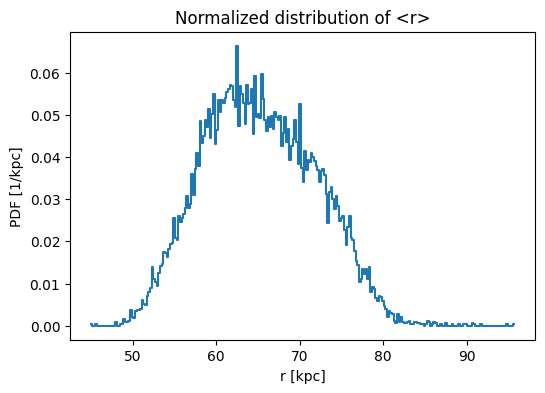

In [5]:
u = units_and_constants()
M = 2.0e11 * u.Msun
z = 2.0
c = 10.0  # c200
n = 2**14

print(f"\nSampling {n} subhalos in M={M/u.Msun:.2e} Msun, z={z}, c200={c}...\n")

# そのまま（既定で '200c'）
rmean, extras = sample_rmean_batch(M, z, c, n=n, seed=42, nbins=256)

Rvir_kpc = float(extras["halo"]["Rvir"] / u.kpc)
print("Rvir [kpc] =", Rvir_kpc)
print("⟨r⟩ [kpc]: min/mean/max =",
      float(np.nanmin(rmean)/u.kpc),
      float(np.nanmean(rmean)/u.kpc),
      float(np.nanmax(rmean)/u.kpc))

# プロット
import matplotlib.pyplot as plt
ax = plot_r_pdf(extras, xunit="kpc", logy=False)
plt.show()

# Theoretical Distribution?


Suppose that the initial distribution of SH is given by a distribution function $f_{SH}(E,L)$ times the delta function to restrict the accretion radius to be at $r_{acc}$:

$$
f_i(E,L,L_z,\Omega_E,\Omega_L,\Omega_{L_z}) = f_{SH}(E,L)\delta(r - r_{acc})
$$

where $\Omega_E$, $\Omega_L$, and $\Omega_{L_z}$ are the angle variables corresponding to the integrals of motion $E$, $L$, and $L_z$.

During the dynamical evolution of subhalo population, the distribution of SH experiences the phase mixing, which tends to smooth out the distribution in the phase space. After a long time, the distribution of SH should be a function of the integrals of motion only, i.e., $f_f(E,L)$. The final distribution can be obtained by integrating over the phase space with the delta function:

$$
f_f(E,L) = \int f_i(E,L,L_z,\Omega_E,\Omega_L,\Omega_{L_z}) d\Omega_E d\Omega_L d\Omega_{L_z}
$$

## Angle-Action variables

Here is the table of angle-action variables for spherical potentials from Binney & Tremaine (2008), Section 3.5.2.

- $J_r = \frac{1}{\pi} \int_{r_{peri}}^{r_{apo}} dr \sqrt{2E - 2\Phi(r) - L^2/r^2}$
- $J_\theta = L - |L_z| = \int d\theta \sqrt{L^2 - L_z^2/\sin^2\theta}$
- $J_\phi = L_z$

or 

- $J_1 = J_z$
- $J_2 = L$
- $J_3 = J_r$

Here the Hamiltonian is a function of actions only: $H = H(J_2, J_3)$. Thus,

- $\Omega_1 = \frac{\partial H}{\partial J_1} = 0$
- $\Omega_2 = \frac{\partial H}{\partial J_2}$
- $\Omega_3 = \frac{\partial H}{\partial J_3}$

<Quantity 1.e+12 solMass>

<Quantity 211.00805482 kpc>

conc: 10.000000000000021


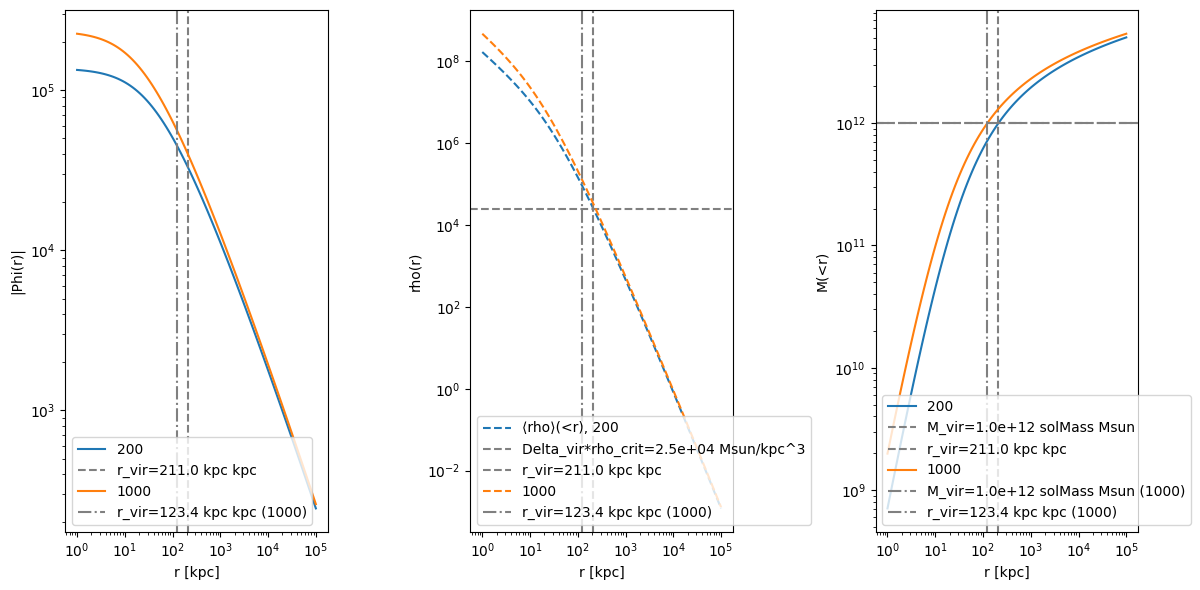

10.00000000000002


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from galpy.potential import NFWPotential as NFWPotentialGalpy
from galpy.actionAngle import actionAngleSpherical
from galpy.orbit import Orbit
from astropy import units as u
from astropy.cosmology import Planck18

class NFWPotential(NFWPotentialGalpy):
    def __init__(self,mvir,conc,cosmology=Planck18):
        cosmo_kwargs = {
            "H": cosmology.H0.to_value(u.km / u.s / u.Mpc)
            "Om": cosmology.Om0,
            "wrtcrit": True,
            "overdens": 200
        }
        super().__init__(mvir=mvir,conc=conc,**cosmo_kwargs)
        self.cosmo_kwargs = cosmo_kwargs

    @property
    def conc(self):
        return super().conc(**self.cosmo_kwargs)
    
    @property
    def mvir(self):
        return super().mvir(**self.cosmo_kwargs)
    
    @property
    def rmax(self):
        return super().rmax(**self.cosmo_kwargs)
    
    @property
    def rvir(self):
        return super().rvir(**self.cosmo_kwargs)

    @property
    def vmax(self):
        return super().vmax(**self.cosmo_kwargs)
    


# play with the galpy objects
overdens = 200
kwargs = {
    "H": Planck18.H0.to_value(u.km / u.s / u.Mpc)
    "Om": Planck18.Om0,
    "wrtcrit": True,
    "overdens": overdens
}
nfw = NFWPotential(mvir=1,conc=10,**kwargs)
crit0 = Planck18.critical_density0.to(u.Msun / u.kpc**3)
mvir = nfw.mvir(**kwargs)
rvir = nfw.rvir(**kwargs)
display(nfw)
display(mvir)
display(rvir)
r = np.logspace(0, 5, 100) * u.kpc
phi = nfw(r, z=0)
rho = nfw.dens(r, z=0).to(u.Msun / u.kpc**3)
rho_mean = (nfw.mass(r) / (4.0/3.0 * np.pi * r**3)).to(u.Msun / u.kpc**3)
mass = nfw.mass(r).to(u.Msun)
print("conc:", nfw.conc(**kwargs))
fig,axes = plt.subplots(1,3, figsize=(12,6))
axes[0].loglog(r, -phi, label='200')
axes[0].set_ylabel("|Phi(r)|")
# axes[1].loglog(r, rho, label='rho(r), 200')
axes[1].loglog(r, rho_mean, ls='--', label='⟨rho⟩(<r), 200')
axes[1].set_ylabel("rho(r)")
axes[1].axhline(crit0.value * overdens, color='gray', ls='--', label=f'Delta_vir*rho_crit={crit0.value * overdens:.1e} Msun/kpc^3')
axes[2].loglog(r, mass, label='200')
axes[2].set_ylabel("M(<r)")
axes[2].axhline(mvir.value, color='gray', ls='--', label=f'M_vir={mvir:.1e} Msun')
for ax in axes:
    ax.set_xlabel("r [kpc]")
    ax.axvline(rvir.value, color='gray', ls='--', label=f'r_vir={rvir:.1f} kpc')
    ax.legend()
# for overdens = 178?
overdens = 1000
kwargs["overdens"] = overdens
nfw = NFWPotential(mvir=1,conc=10,**kwargs)
rvir = nfw.rvir(use_physical=True,**kwargs)
mvir = nfw.mvir(use_physical=True,**kwargs)
phi = nfw(r, z=0)
rho = nfw.dens(r, z=0).to(u.Msun / u.kpc**3)
rho_mean = (nfw.mass(r) / (4.0/3.0 * np.pi * r**3)).to(u.Msun / u.kpc**3)
mass = nfw.mass(r).to(u.Msun)
axes[0].loglog(r, -phi, label=overdens)
# axes[1].loglog(r, rho, label=overdens)
axes[1].loglog(r, rho_mean, ls='--', label=overdens)
axes[2].loglog(r, mass, label=overdens)
axes[2].axhline(mvir.value, color='gray', ls='-.', label=f'M_vir={mvir:.1e} Msun ({overdens})')
for ax in axes:
    ax.axvline(rvir.value, color='gray', ls='-.', label=f'r_vir={rvir:.1f} kpc ({overdens})')
    ax.legend()
plt.tight_layout()
plt.show()
print(nfw.conc(**kwargs))

In [70]:
Planck18.H0.to_value(u.km / u.s / u.Mpc)

np.float64(67.66)

In [10]:
action_angle = actionAngleSpherical(pot=nfw)
action_angle(
    1.0,
    0.0,
    0.0,
    20.0,
    20.0,
    0.0
)

UnboundError: 'Orbit seems to be unbound'

In [6]:
import numpy as np
from scipy.optimize import brentq

# ----------------------------
# core: r(t) for one orbit (E,L) given initial radius r0 and initial radial sign s = +/-1
# ----------------------------
def _g_vr2(r, E, L, rs, Vs2):
    # v_r^2 = 2(E - Phi) - L^2/r^2
    phi = Phi_NFW(r, rs, Vs2)
    return 2.0 * (E - phi) - (L * L) / (r * r)

def turning_points_NFW(E, L, r0, halo, *, rmin=None, rmax_limit=None, expand=1.6, max_iter=64):
    """
    Find pericenter rp and apocenter ra for bound orbit in NFW (Phi(inf)=0),
    assuming r0 is inside the allowed region (v_r^2(r0) >= 0).

    Returns (rp, ra). If it looks (numerically) circular, returns (r0, r0).
    """
    rs  = halo["rs"]
    Vs2 = halo["Vs2"]
    Rvir = halo["Rvir"]

    if rmin is None:
        # small but nonzero
        rmin = max(1e-10 * float(rs), 1e-12 * float(Rvir))

    if rmax_limit is None:
        # far enough so that g(r)->2E<0 becomes negative for bound E<0
        rmax_limit = 50.0 * float(Rvir)

    E = float(E)
    L = float(L)
    r0 = float(r0)

    g0 = _g_vr2(r0, E, L, rs, Vs2)
    if not np.isfinite(g0):
        return np.nan, np.nan
    if g0 < 0.0:
        # cannot start at r0 for this (E,L)
        return np.nan, np.nan

    # Handle near-circular / turning-point start:
    # If g0 is ~0 and g is negative on both sides (no radial range), treat as circular.
    tol_circ = 1e-14 * max(1.0, abs(2*E))
    if abs(g0) < tol_circ:
        # Try probing slightly inside/outside to see if there is a positive region
        rin  = max(rmin, r0 * 0.9)
        rout = min(rmax_limit, r0 * 1.1)
        gin  = _g_vr2(rin,  E, L, rs, Vs2)
        gout = _g_vr2(rout, E, L, rs, Vs2)
        if (gin <= 0.0) and (gout <= 0.0):
            return r0, r0  # numerically circular / at a hard turning point

    # --- pericenter: root in (rmin, r0) if possible
    gL = _g_vr2(rmin, E, L, rs, Vs2)
    if not np.isfinite(gL):
        return np.nan, np.nan

    if gL < 0.0 and g0 > 0.0:
        rp = brentq(lambda rr: _g_vr2(rr, E, L, rs, Vs2), rmin, r0, maxiter=200)
    elif gL <= 0.0 and g0 == 0.0:
        rp = r0
    else:
        # e.g. very small L case where g(rmin) may not be negative; fall back
        rp = rmin

    # --- apocenter: find r_hi > r0 such that g(r_hi) < 0, then root in (r0, r_hi)
    r_hi = r0 * 1.05
    for _ in range(max_iter):
        if r_hi >= rmax_limit:
            break
        g_hi = _g_vr2(r_hi, E, L, rs, Vs2)
        if np.isfinite(g_hi) and (g_hi < 0.0):
            break
        r_hi *= expand

    if r_hi >= rmax_limit:
        # couldn't bracket; likely unbound or rmax_limit too small
        return np.nan, np.nan

    # If g0==0 (start at turning point), brentq needs sign change; nudge lower bound
    r_lo = r0
    if abs(g0) < tol_circ:
        r_lo = r0 * 1.000001

    ra = brentq(lambda rr: _g_vr2(rr, E, L, rs, Vs2), r_lo, r_hi, maxiter=200)

    return float(rp), float(ra)

def r_at_time_one_orbit(E, L, r0, sgn, t, halo, *,
                        n_theta=512, rmin=None, rmax_limit=None):
    """
    Compute r(t) for one bound orbit using radial-phase inversion.
    sgn = +1 (outward) or -1 (inward) selects initial radial direction at r0.
    """
    rs  = halo["rs"]
    Vs2 = halo["Vs2"]

    E = float(E); L = float(L); r0 = float(r0); t = float(t)

    rp, ra = turning_points_NFW(E, L, r0, halo, rmin=rmin, rmax_limit=rmax_limit)
    if not (np.isfinite(rp) and np.isfinite(ra)):
        return np.nan

    if abs(ra - rp) < 1e-15 * max(1.0, abs(r0)):
        # circular / degenerate
        return r0

    if not (rp <= r0 <= ra):
        return np.nan

    # theta grid for the sin^2 map (stable near turning points)
    theta = np.linspace(0.0, 0.5*np.pi, int(n_theta), dtype=float)
    dth   = theta[1] - theta[0]
    sin2  = np.sin(theta)**2
    sin2th = np.sin(2.0*theta)

    r_grid = rp + (ra - rp) * sin2
    dr_dth = (ra - rp) * sin2th

    g = _g_vr2(r_grid, E, L, rs, Vs2)
    g = np.maximum(g, 0.0)
    vr = np.sqrt(g)

    # integrand for tau(theta) = ∫ dr/vr = ∫ (dr/dθ)/vr dθ
    integrand = np.zeros_like(theta)
    good = vr > 0.0
    integrand[good] = dr_dth[good] / vr[good]

    # cumulative trapezoid in theta
    dtau = 0.5 * (integrand[:-1] + integrand[1:]) * dth
    tau_grid = np.empty_like(theta)
    tau_grid[0] = 0.0
    tau_grid[1:] = np.cumsum(dtau)

    tau_end = tau_grid[-1]      # time from rp to ra along outward leg
    Tr      = 2.0 * tau_end     # full radial period

    if Tr <= 0.0 or not np.isfinite(Tr):
        return np.nan

    # initial phase tau0 on outward leg (invert r->tau)
    tau0_out = np.interp(r0, r_grid, tau_grid)

    # choose initial direction
    tau0 = tau0_out if (sgn >= 0) else (Tr - tau0_out)

    # advance phase
    tau_t = (tau0 + t) % Tr

    # map back to radius
    if tau_t <= tau_end:
        r_t = np.interp(tau_t, tau_grid, r_grid)            # outward branch
    else:
        r_t = np.interp(Tr - tau_t, tau_grid, r_grid)       # inward branch

    return float(r_t)

def r_at_time_batch(E, L, r0, t, halo, *,
                    sign_mode="random", seed=None,
                    n_theta=512, rmin=None, rmax_limit=None):
    """
    Vector wrapper. Returns r_t for each sample.

    sign_mode:
      - "random": random +/- with equal prob (recommended for delta shell)
      - "both":   returns 2N samples by stacking both signs (symmetric average)
      - "out":    all +1
      - "in":     all -1
    """
    rng = np.random.default_rng(seed)
    E = np.asarray(E, float)
    L = np.asarray(L, float)
    r0 = np.asarray(r0, float)
    assert E.shape == L.shape == r0.shape

    if sign_mode == "both":
        E2 = np.concatenate([E, E])
        L2 = np.concatenate([L, L])
        r02 = np.concatenate([r0, r0])
        sgn = np.concatenate([np.ones_like(E), -np.ones_like(E)])
    elif sign_mode == "random":
        sgn = rng.choice(np.array([-1.0, 1.0]), size=E.shape[0])
        E2, L2, r02 = E, L, r0
    elif sign_mode == "out":
        sgn = np.ones_like(E)
        E2, L2, r02 = E, L, r0
    elif sign_mode == "in":
        sgn = -np.ones_like(E)
        E2, L2, r02 = E, L, r0
    else:
        raise ValueError("sign_mode must be one of: random, both, out, in")

    r_t = np.empty(E2.shape[0], dtype=float)
    for i in range(E2.shape[0]):
        r_t[i] = r_at_time_one_orbit(
            E2[i], L2[i], r02[i], sgn[i], t, halo,
            n_theta=n_theta, rmin=rmin, rmax_limit=rmax_limit
        )
    return r_t

# ----------------------------
# high-level: sample (E,L) with your recipe, evolve to time t, and build radial PDF + moments
# ----------------------------
def radial_pdf_at_time_from_sampling(M, z, c, t, *,
                                     n=4000, seed=0, mass_def="200c", h=0.7,
                                     sign_mode="random",
                                     n_theta=512,
                                     nbins=40, rmin=None, rmax=None):
    """
    Uses your sample_EL_from_eta_Rc(...) (E,L,eta,Rc,H) where Rc is treated as initial radius r0.
    Returns: dict with r_t, pdf, moments, and the halo dict.
    """
    u = units_and_constants()

    E, L, eta, Rc, halo = sample_EL_from_eta_Rc(M, z, c, n=n, seed=seed, mass_def=mass_def, h=h)
    # initial radius shell per particle (your sampling naturally defines r0 = Rc)
    r0 = Rc

    # evolve
    r_t = r_at_time_batch(E, L, r0, t, halo, sign_mode=sign_mode, seed=seed,
                          n_theta=n_theta)

    # drop failures
    r_t = r_t[np.isfinite(r_t)]
    if r_t.size == 0:
        raise RuntimeError("All trajectories failed (check t units, orbits bound, brackets, etc.).")

    # build PDF (reuse your helper)
    centers_kpc, pdf_per_kpc, edges_kpc = radial_pdf(r_t, nbins=nbins,
                                                     rmin=rmin, rmax=rmax)

    # moments at time t
    r_mean = np.mean(np.asarray(r_t, float))
    r_var  = np.var (np.asarray(r_t, float))

    out = dict(
        r_t=r_t,
        moments=dict(mean=r_mean, var=r_var),
        r_pdf=dict(centers=centers_kpc, pdf=pdf_per_kpc, edges=edges_kpc),
        halo=halo,
        extras=dict(E=E, L=L, eta=eta, Rc=Rc),
    )
    return out


<Axes: title={'center': 'Normalized distribution of <r>'}, xlabel='r [kpc]', ylabel='PDF [1/kpc]'>

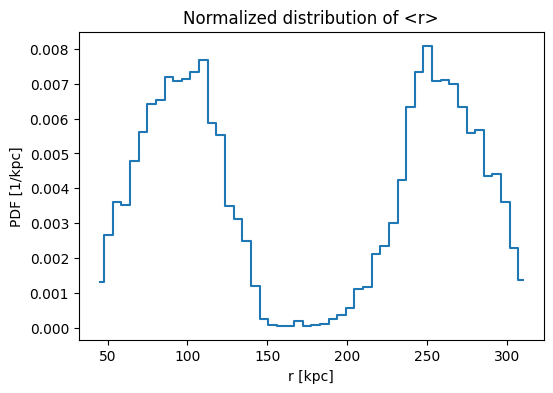

In [ ]:
u = units_and_constants()
M = 1e12 * u.Msun
z = 0.5
c = 8.0

t = 1e9 * u.yr  # ← ここはあなたの units に合わせて

out = radial_pdf_at_time_from_sampling(
    M, z, c, t,
    n=6000, seed=1,
    sign_mode="random",   # "both" にするとサンプル2倍で対称平均
    n_theta=512,
    nbins=50
)

# out["r_t"] が r(t) サンプル
# out["r_pdf"] が f(r,t) のヒストグラム推定
# out["moments"]["mean"], ["var"] が <r>|t と Var(r)|t
plot_r_pdf(out, xunit="kpc", logy=False)  # あなたの helper をそのまま使える形


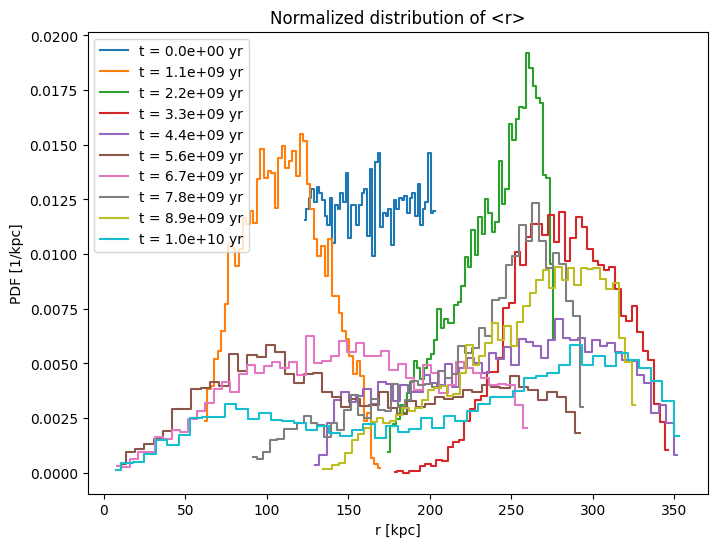

In [20]:
u = units_and_constants()
M = 1e12 * u.Msun
z = 0.5
c = 8.0
u.Gyr = 1e9 * u.yr

fig,ax = plt.subplots(figsize=(8,6))
# t_list = [ _t * u.yr for _t in np.linspace(0, 5e9, 10) ]
t_list = [ _t * u.Gyr for _t in np.linspace(0, 10, 10) ]
for t in t_list:

    out = radial_pdf_at_time_from_sampling(
        M, z, c, t,
        n=6000, seed=1,
        sign_mode="in",   # "both" にするとサンプル2倍で対称平均
        n_theta=512,
        nbins=50
    )

    # out["r_t"] が r(t) サンプル
    # out["r_pdf"] が f(r,t) のヒストグラム推定
    # out["moments"]["mean"], ["var"] が <r>|t と Var(r)|t
    ax = plot_r_pdf(out, xunit="kpc", logy=False, ax=ax)  # あなたの helper をそのまま使える形
ax.legend([f"t = {t/u.yr:.1e} yr" for t in t_list])


t_dyn = 10.811502114861822 Gyr (median Tr)


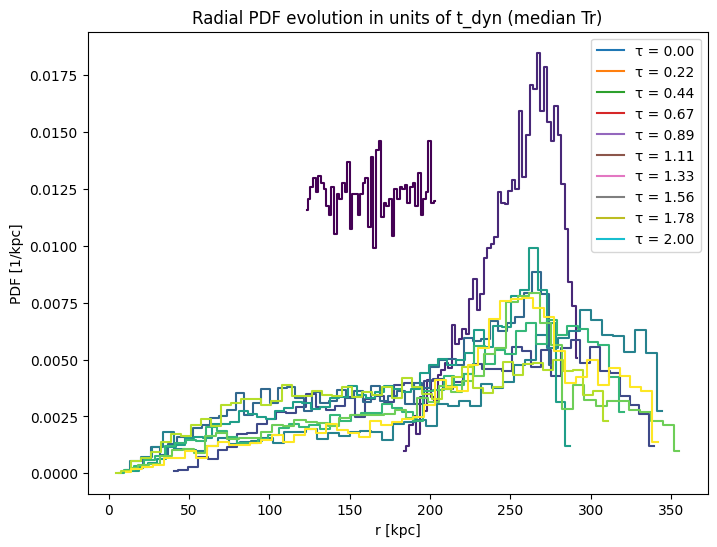

In [ ]:
import numpy as np

# --- NFW enclosed mass using your halo dict (Mvir, Rvir, rs, cvir, ...)
def Menc_NFW(r, halo):
    # M(<r) = Mvir * f(x) / f(cvir), x=r/rs
    rs   = halo["rs"]
    Mvir = halo["Mvir"]
    cvir = halo["cvir"]

    x = np.asarray(r, float) / float(rs)
    fx = np.log1p(x) - x/(1.0 + x)
    fc = np.log1p(float(cvir)) - float(cvir)/(1.0 + float(cvir))
    return Mvir * (fx / fc)

def Vc_NFW(r, halo):
    u = units_and_constants()
    return np.sqrt(u.G * Menc_NFW(r, halo) / r)

# --- (A) circular orbital period at radius r: T_circ = 2π r / Vc(r)
def t_dyn_circular(r, halo):
    return 2.0*np.pi * r / Vc_NFW(r, halo)

# --- (B) free-fall / dynamical time from mean density inside r
#   t_ff = sqrt(3π/(32 G rho_bar)), often "dynamical time" is ~2*t_ff
def t_ff_mean_density(r, halo):
    u = units_and_constants()
    M = Menc_NFW(r, halo)
    rho_bar = 3.0*M / (4.0*np.pi*r**3)
    return np.sqrt(3.0*np.pi / (32.0*u.G*rho_bar))

def t_dyn_mean_density(r, halo):
    # common "dynamical time" definition: sqrt(3π/(16 G rho_bar)) = 2*t_ff
    return 2.0 * t_ff_mean_density(r, halo)

# --- (C) "sample-based" dynamical time: median radial period Tr from your sampled (E,L)
def t_dyn_median_Tr_from_samples(M, z, c, *, n=6000, seed=1, mass_def="200c", h=0.7,
                                 nr=4096, rmax_factor_Rvir=5.0):
    u = units_and_constants()
    E, L, eta, Rc, halo = sample_EL_from_eta_Rc(M, z, c, n=n, seed=seed, mass_def=mass_def, h=h)
    rmean, rp, ra, Tr   = time_averaged_radius_batch_halo(E, L, halo, nr=nr, rmax_factor_Rvir=rmax_factor_Rvir)
    Tr_num = np.asarray(Tr, float)
    Tr_num = Tr_num[np.isfinite(Tr_num) & (Tr_num > 0)]
    return np.median(Tr_num) * u.s, halo  # attach unit back via u.s


import matplotlib.pyplot as plt
import numpy as np

u = units_and_constants()
u.Gyr = 1e9 * u.yr
M = 1e12 * u.Msun
z = 0.5
c = 8.0

# --- compute dynamical time (median radial period) once
t_dyn, halo = t_dyn_median_Tr_from_samples(M, z, c, n=6000, seed=1)

print("t_dyn =", float(t_dyn/u.Gyr), "Gyr (median Tr)")

# --- use dimensionless time tau = t/t_dyn
tau_list = np.linspace(0, 2, 10)   # 0〜10 dynamical times
t_list   = [tau * t_dyn for tau in tau_list]

fig, ax = plt.subplots(figsize=(8,6))

for tau, t in zip(tau_list, t_list):
    out = radial_pdf_at_time_from_sampling(
        M, z, c, t,
        n=6000, seed=1,
        sign_mode="in",
        n_theta=512,
        nbins=50,
    )
    ax = plot_r_pdf(out, xunit="kpc", logy=False, ax=ax)


cmap = plt.get_cmap("viridis")
for tau,line in zip(tau_list, ax.get_lines()):
    line.set_color(cmap(tau / max(tau_list)))
ax.legend([f"τ = {tau:.2f}" for tau in tau_list])
ax.set_title("Radial PDF evolution in units of t_dyn (median Tr)")
plt.show()



t_dyn (median Tr) = 10.811502114861822 Gyr


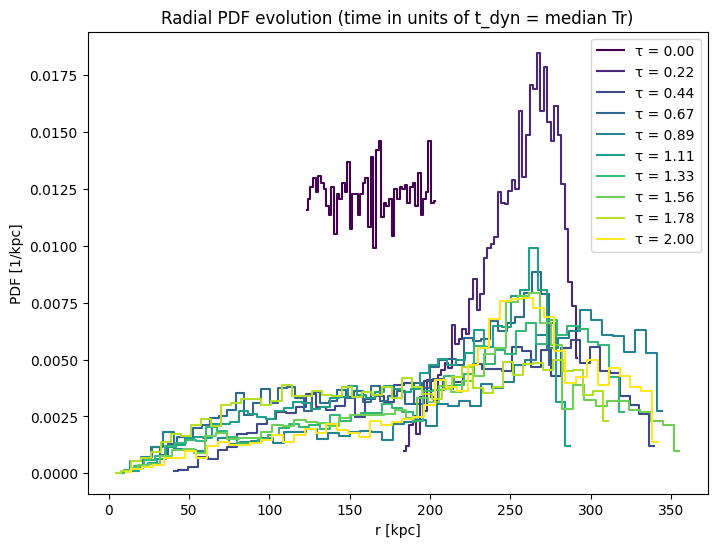

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# 既にあなたが持っている:
# - units_and_constants, sample_EL_from_eta_Rc
# - radial_pdf
# - plot_r_pdf
# - time_averaged_radius_batch_halo
# - r_at_time_batch (前に提示したもの)

u = units_and_constants()
u.Gyr = 1e9 * u.yr
M = 1e12 * u.Msun
z = 0.5
c = 8.0

# ---- 1) 初期サンプルは一回だけ ----
n = 6000
seed = 1
E, L, eta, Rc, halo = sample_EL_from_eta_Rc(M, z, c, n=n, seed=seed, mass_def="200c")

# ---- 2) dynamical time: サンプルの median(Tr) を採用（おすすめ）----
_, _, _, Tr = time_averaged_radius_batch_halo(E, L, halo, nr=4096, rmax_factor_Rvir=5.0)

Tr_num = np.asarray(Tr, float)
Tr_num = Tr_num[np.isfinite(Tr_num) & (Tr_num > 0)]
t_dyn = np.median(Tr_num) * u.s   # [time]

print("t_dyn (median Tr) =", float(t_dyn/u.Gyr), "Gyr")

# ---- 3) τ=t/t_dyn で時間リストを作る ----
tau_list = np.linspace(0.0, 2.0, 10)  # 0〜10 dynamical times
t_list   = [tau * t_dyn for tau in tau_list]

# ---- 4) 同じ (E,L,r0) を流して f(r,t) を作る ----
fig, ax = plt.subplots(figsize=(8,6))

for tau, t in zip(tau_list, t_list):
    r_t = r_at_time_batch(E, L, Rc, t, halo,
                          sign_mode="in", seed=seed, n_theta=512)
    r_t = r_t[np.isfinite(r_t)]
    centers_kpc, pdf_per_kpc, edges_kpc = radial_pdf(r_t, nbins=50)

    # plot_r_pdf が extras を要求するなら、それに合わせて dict を作る
    extras = {"r_pdf": {"centers": centers_kpc, "pdf": pdf_per_kpc, "edges": edges_kpc}}
    ax = plot_r_pdf(extras, xunit="kpc", logy=False, ax=ax)

cmap = plt.get_cmap("viridis")
for tau,line in zip(tau_list, ax.get_lines()):
    line.set_color(cmap(tau / max(tau_list)))
ax.legend([f"τ = {tau:.2f}" for tau in tau_list])
ax.set_title("Radial PDF evolution (time in units of t_dyn = median Tr)")
plt.show()


In [35]:
import numpy as np
from scipy.optimize import brentq
from tqdm import tqdm, trange

# ---------- core physics helpers ----------
def _g_vr2(r, E, L, rs, Vs2):
    # v_r^2 = 2(E - Phi) - L^2/r^2
    phi = Phi_NFW(r, rs, Vs2)
    return 2.0 * (E - phi) - (L * L) / (r * r)

def turning_points_NFW(E, L, r0, halo, *, rmin=None, rmax_limit=None,
                       expand=1.6, max_iter=64):
    rs   = halo["rs"]
    Vs2  = halo["Vs2"]
    Rvir = halo["Rvir"]

    E  = float(E)
    L  = float(L)
    r0 = float(r0)

    if rmin is None:
        rmin = max(1e-12 * float(Rvir), 1e-10 * float(rs))
    if rmax_limit is None:
        rmax_limit = 50.0 * float(Rvir)

    g0 = _g_vr2(r0, E, L, rs, Vs2)
    if not np.isfinite(g0) or g0 < 0.0:
        return np.nan, np.nan

    # near-circular / start at turning point: handle gently
    tol = 1e-14 * max(1.0, abs(2*E))
    if abs(g0) < tol:
        rin  = max(rmin, r0 * 0.9)
        rout = min(rmax_limit, r0 * 1.1)
        gin  = _g_vr2(rin,  E, L, rs, Vs2)
        gout = _g_vr2(rout, E, L, rs, Vs2)
        if (np.isfinite(gin) and gin <= 0.0) and (np.isfinite(gout) and gout <= 0.0):
            return r0, r0  # effectively circular

    # pericenter bracket in (rmin, r0)
    gL = _g_vr2(rmin, E, L, rs, Vs2)
    if np.isfinite(gL) and (gL < 0.0) and (g0 > 0.0):
        rp = brentq(lambda rr: _g_vr2(rr, E, L, rs, Vs2), rmin, r0, maxiter=200)
    else:
        rp = rmin

    # apocenter: find r_hi > r0 with g(r_hi) < 0 then root
    r_hi = r0 * 1.05
    for _ in range(max_iter):
        if r_hi >= rmax_limit:
            return np.nan, np.nan
        g_hi = _g_vr2(r_hi, E, L, rs, Vs2)
        if np.isfinite(g_hi) and (g_hi < 0.0):
            break
        r_hi *= expand

    r_lo = r0 if abs(g0) >= tol else (r0 * 1.000001)
    ra = brentq(lambda rr: _g_vr2(rr, E, L, rs, Vs2), r_lo, r_hi, maxiter=200)
    return float(rp), float(ra)

def build_orbit_cache(E, L, r0, halo, *, n_theta=512, rmin=None, rmax_limit=None):
    """
    Precompute per-orbit phase table for fast r(t).
    Returns cache dict with arrays and grids.
    """
    rs  = halo["rs"]
    Vs2 = halo["Vs2"]

    E  = np.asarray(E, float)
    L  = np.asarray(L, float)
    r0 = np.asarray(r0, float)
    assert E.shape == L.shape == r0.shape
    n = E.size

    # fixed theta grid for all orbits (sin^2 mapping)
    theta = np.linspace(0.0, 0.5*np.pi, int(n_theta), dtype=float)
    dth   = theta[1] - theta[0]
    sin2  = np.sin(theta)**2
    sin2th = np.sin(2.0*theta)

    # allocate
    rp  = np.full(n, np.nan, float)
    ra  = np.full(n, np.nan, float)
    Tr  = np.full(n, np.nan, float)
    tau0_out = np.full(n, np.nan, float)  # phase on outward leg (rp->ra)

    # store grids per orbit (n_theta each)
    r_grid  = np.full((n, n_theta), np.nan, float)
    tau_grid = np.full((n, n_theta), np.nan, float)
    tau_end = np.full(n, np.nan, float)   # time from rp to ra

    for i in trange(n, desc="Building orbit cache"):
        _rp, _ra = turning_points_NFW(E[i], L[i], r0[i], halo, rmin=rmin, rmax_limit=rmax_limit)
        if not (np.isfinite(_rp) and np.isfinite(_ra)):
            continue
        rp[i], ra[i] = _rp, _ra

        if abs(_ra - _rp) < 1e-15 * max(1.0, abs(r0[i])):
            # circular / degenerate: treat as Tr ~ 0, and r(t)=r0 always
            Tr[i] = 0.0
            tau0_out[i] = 0.0
            r_grid[i, :] = r0[i]
            tau_grid[i, :] = 0.0
            tau_end[i] = 0.0
            continue

        # build r(theta) and tau(theta)
        rg = _rp + (_ra - _rp) * sin2
        drd = (_ra - _rp) * sin2th

        g = _g_vr2(rg, E[i], L[i], rs, Vs2)
        g = np.maximum(g, 0.0)
        vr = np.sqrt(g)

        integrand = np.zeros_like(theta)
        good = vr > 0.0
        integrand[good] = drd[good] / vr[good]

        dtau = 0.5 * (integrand[:-1] + integrand[1:]) * dth
        tg = np.empty_like(theta)
        tg[0] = 0.0
        tg[1:] = np.cumsum(dtau)

        te = tg[-1]
        T  = 2.0 * te

        if not (np.isfinite(T) and T > 0.0):
            continue

        # invert r0 -> tau0 on outward leg (rp->ra)
        # (rg is increasing, so interp is OK)
        t0 = np.interp(r0[i], rg, tg)

        r_grid[i, :] = rg
        tau_grid[i, :] = tg
        tau_end[i] = te
        Tr[i] = T
        tau0_out[i] = t0

    cache = dict(
        E=E, L=L, r0=r0,
        rp=rp, ra=ra, Tr=Tr,
        r_grid=r_grid, tau_grid=tau_grid, tau_end=tau_end,
        tau0_out=tau0_out,
        theta=theta, halo=halo,
    )
    return cache

def evolve_r_from_cache(cache, t, *, sign_mode="in", seed=None, signs=None):
    """
    Fast r(t) using cached tables.

    sign_mode:
      - "in" / "out": fixed initial radial sign for all particles
      - "random": random +/- per particle (seeded) unless 'signs' is provided
      - "both": returns stacked 2N (out then in)
    """
    rng = np.random.default_rng(seed)

    Tr = cache["Tr"]
    te = cache["tau_end"]
    t0 = cache["tau0_out"]
    rg = cache["r_grid"]
    tg = cache["tau_grid"]

    n = Tr.size
    t = float(t)

    valid = np.isfinite(Tr) & (Tr > 0.0) & np.isfinite(te) & np.isfinite(t0)
    # include circular (Tr==0): valid separately
    circ = np.isfinite(Tr) & (Tr == 0.0) & np.isfinite(cache["r0"])
    valid_any = valid | circ

    def _one_branch(tau0):
        rt = np.full(n, np.nan, float)

        # circular
        rt[circ] = cache["r0"][circ]

        idx = np.where(valid)[0]
        if idx.size == 0:
            return rt

        Tr_i = Tr[idx]
        te_i = te[idx]
        tau_t = (tau0[idx] + t) % Tr_i

        # invert per orbit (needs loop because each orbit has own tau_grid)
        for k, i in enumerate(idx):
            if tau_t[k] <= te_i[k]:
                rt[i] = np.interp(tau_t[k], tg[i], rg[i])
            else:
                rt[i] = np.interp(Tr_i[k] - tau_t[k], tg[i], rg[i])
        return rt

    if sign_mode == "out":
        return _one_branch(t0)

    if sign_mode == "in":
        tau0_in = Tr - t0
        return _one_branch(tau0_in)

    if sign_mode == "random":
        if signs is None:
            s = rng.choice(np.array([-1.0, 1.0]), size=n)
        else:
            s = np.asarray(signs, float)
            assert s.shape == (n,)
        tau0_in = Tr - t0
        # tau0 = t0 for out, Tr-t0 for in
        tau0 = np.where(s >= 0.0, t0, tau0_in)
        return _one_branch(tau0)

    if sign_mode == "both":
        out = _one_branch(t0)
        inn = _one_branch(Tr - t0)
        return np.concatenate([out, inn])

    raise ValueError("sign_mode must be one of: in, out, random, both")

def t_dyn_from_cache(cache, *, method="median_Tr"):
    """
    Choose a representative dynamical time from cached radial periods.
    """
    u = units_and_constants()
    Tr = cache["Tr"]
    Tr = Tr[np.isfinite(Tr) & (Tr > 0.0)]
    if Tr.size == 0:
        raise RuntimeError("No valid bound orbits to define t_dyn.")
    if method == "median_Tr":
        return np.median(Tr) * u.s
    if method == "mean_Tr":
        return np.mean(Tr) * u.s
    raise ValueError("method must be 'median_Tr' or 'mean_Tr'")


Building orbit cache: 100%|██████████| 6000/6000 [00:01<00:00, 3380.86it/s]


t_dyn = 5.427064587782832 Gyr


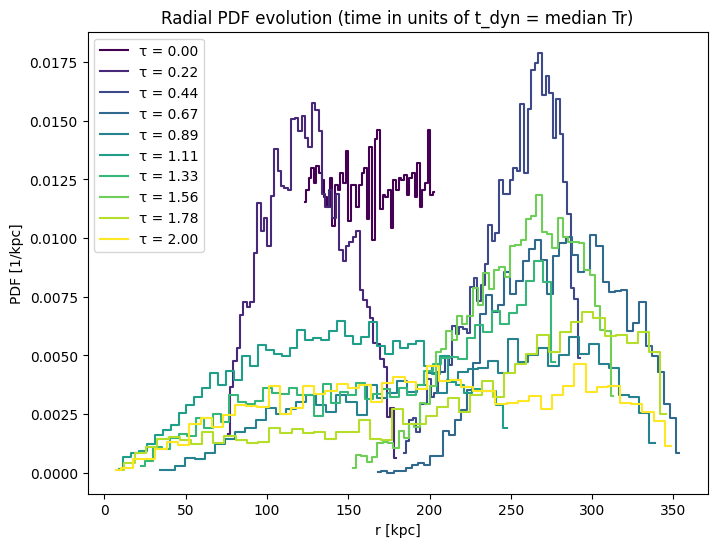

In [38]:
import numpy as np
import matplotlib.pyplot as plt

u = units_and_constants(); u.Gyr = 1e9 * u.yr
M = 1e12 * u.Msun
z = 0.5
c = 8.0

# 1) 初期サンプルは一回だけ
E, L, eta, Rc, halo = sample_EL_from_eta_Rc(M, z, c, n=6000, seed=1, mass_def="200c")

# 2) キャッシュ構築（ここが重い処理。以後は軽い）
cache = build_orbit_cache(E, L, Rc, halo, n_theta=512)

# 3) t_dyn を決める（サンプルの median Tr）
t_dyn = t_dyn_from_cache(cache, method="median_Tr")
print("t_dyn =", float(t_dyn/u.Gyr), "Gyr")

# 4) τ掃引でPDF
tau_list = np.linspace(0.0, 2.0, 10)
t_list   = [tau * t_dyn for tau in tau_list]

fig, ax = plt.subplots(figsize=(8,6))

for tau, t in zip(tau_list, t_list):
    r_t = evolve_r_from_cache(cache, t, sign_mode="in")     # ←あなたの指定と合わせる
    r_t = r_t[np.isfinite(r_t)]

    centers_kpc, pdf_per_kpc, edges_kpc = radial_pdf(r_t, nbins=50)
    extras = {"r_pdf": {"centers": centers_kpc, "pdf": pdf_per_kpc, "edges": edges_kpc}}

    ax = plot_r_pdf(extras, xunit="kpc", logy=False, ax=ax)

for tau,line in zip(tau_list, ax.get_lines()):
    line.set_color(cmap(tau / max(tau_list)))
ax.legend([f"τ = {tau:.2f}" for tau in tau_list])
ax.set_title("Radial PDF evolution (time in units of t_dyn = median Tr)")
plt.show()


# Single file

Sampling orbits (stochastic E,L; placed at r0=Rvir)...
Building orbit cache...


Building orbit cache: 100%|██████████| 60000/60000 [00:25<00:00, 2376.55it/s]


t_dyn = 5.438287724854369 Gyr


Coloring lines: 100%|██████████| 10/10 [00:00<00:00, 20712.61it/s]


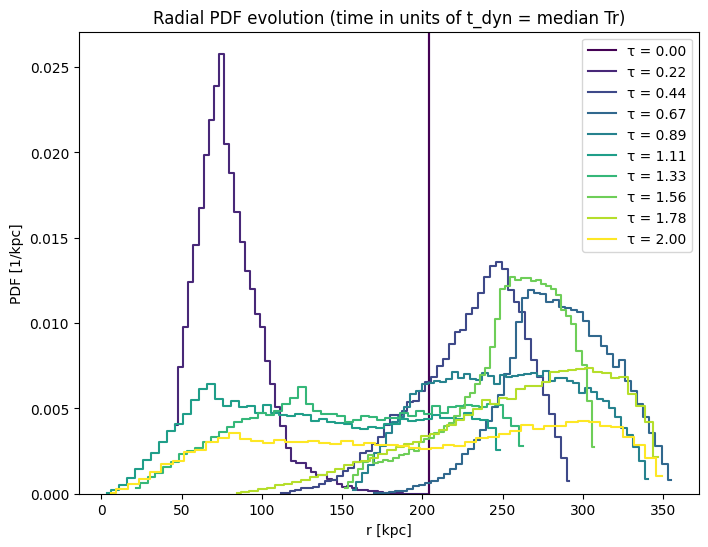

In [1]:
import radial_pdf_evolution_in_units_of_dynamical_time_nfw_cached_phase_tables as rpe
rpe.main()
